# 10 · GNN: 이웃에게서 모으고, 모든 노드에 같은 규칙 쓰기

**이번 질문:** 이미지의 격자나 시간 순서가 아니라, 연결 관계만 주어졌다면 어떤 입력을 모아서 같은 함수를 적용해야 할까요?

05번은 옆 화소를, 06번은 이전 시각을, 08번은 점수가 높은 위치를 읽었습니다. 이번에는 **주어진 edge**가 누구를 읽을지 정합니다.
인접 행렬 → 합·평균 집계 → message passing backward → graph readout → 그래프 분류 → 순열 검산과 표현 한계를 구현합니다. 00의 행렬곱, 03의 MLP, 05·06의 가중치 공유를 연결합니다.

- 준비물: [00](../00_기초/00_math_to_numpy.ipynb)의 행렬곱, [03](../00_기초/03_perceptron_to_mlp.ipynb)의 MLP backward, [05](05_cnn.ipynb)·[06](06_rnn.ipynb)의 "공유한 파라미터의 기울기는 더한다".
- 도착점: 한 층의 message passing과 backward를 직접 쓰고 검산한 뒤, 사슬·별 그래프 분류를 학습시키고 노드 번호를 바꿔도 같은 답이 나오는지 검산합니다.
- 다음 연결: [10b CVNN](10b_cvnn.ipynb)은 노드 번호 대신 신호 전체의 위상을 돌려도 같은 답이 나오는 구조를 복소수 뉴런으로 만듭니다. 기본 아키텍처는 10b까지이고, [11 선형대수](../02_연결/11_linear_algebra.ipynb)부터는 구조가 아니라 학습 목적과 표현을 다룹니다.

### 읽는 법

| 표시 | 뜻 | 어떻게 읽나 |
|---|---|---|
| 🔑 **핵심** | 수식·규칙·코드. 이 노트북이 가르치려는 것 | 남에게 설명할 수 있을 때까지 읽고, 코드를 가리고 다시 써 봅니다 |
| 🔍 **확인** | 검산 결과와 그림의 해석 | 실행해서 눈으로 보고 넘어갑니다. 외울 것은 없습니다 |
| 📎 **참고** | 배경 지식, 환경, 용어의 유래 | 처음 읽을 때는 건너뛰어도 됩니다 |
| ✏️ **연습** | 직접 바꿔 보는 문제 | 손으로 먼저 예상한 뒤 실행합니다 |

새 용어는 처음 나오는 자리에서 **용어** 상자로 한 줄씩 풀이합니다.

**이 노트북에서 반드시 가져갈 세 가지**

1. 인접 행렬의 방향을 먼저 정합니다. $A_{ij}=1$은 **$j$가 $i$에게 보낸다**는 뜻이고, 이웃 합은 `A @ X`, 이웃 평균은 degree로 나눈 `S @ X`입니다. 행이 받는 노드, 열이 보내는 노드입니다.
2. 한 층은 모든 노드에 같은 두 가중치를 씁니다. `Z = X @ Ws + (S @ X) @ Wn + b`, `H = np.tanh(Z)`. backward에서 이웃 경로는 **S의 전치**로 돌아갑니다. `dX = dZ @ Ws.T + S.swapaxes(-1, -2) @ (dZ @ Wn.T)`.
3. 노드 번호를 바꾸면 `X[perm]`, `A[perm][:, perm]`처럼 행과 열을 함께 바꿉니다. 노드 출력은 같은 순열로 바뀌고(등변), 평균 readout과 그래프 logits는 그대로입니다(불변).

📎 여기서는 작고 조밀한 인접 행렬을 씁니다. 대규모 sparse 연산이나 라이브러리 호출 안에 집계·미분을 숨기지 않고, 계산을 직접 확인하는 것이 목적입니다.

[전체 학습 경로](../../docs/CURRICULUM.md) · [글 규칙](../../docs/WRITING.md) · [그림 설계](../../docs/DESIGN.md) · [그림 보조 코드](../../src/utils/gnn_plots.py)

In [1]:
# 준비 셀: 실행만 하고 넘어가도 됩니다.
# 1) 프로젝트 루트를 import 경로에 넣습니다. 노트북을 어느 폴더에서 열어도 src/를 찾기 위해서입니다.
import sys
from pathlib import Path
project_root = next(p for p in (Path.cwd(), *Path.cwd().parents) if (p / "src/utils/plotting.py").is_file())   # 현재 폴더부터 위로 올라가며 src/utils/plotting.py가 있는 첫 폴더
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

# 2) NumPy, 수치미분 도우미(2절: 중심차분 numerical_gradient와 상대오차 rel_error), 연습 검사 도우미, 이 노트북의 그림 함수(src/utils/gnn_plots.py)
import numpy as np
from src.utils import setup_plots
from src.utils.gradcheck import numerical_gradient, rel_error
from src.utils import run_check
from src.utils.gnn_plots import (
    plot_curves, plot_aggregation, plot_layer_paths, plot_hops, plot_two_graphs, plot_permutation,
)

# 3) 그림 설정. 배열 출력은 소수 4자리로 줄여 읽기 쉽게 합니다.
setup_plots()
np.set_printoptions(precision=4, suppress=True)
print("NumPy", np.__version__, "· GNN 준비 완료")

NumPy 2.4.6 · GNN 준비 완료


### 📎 이 노트북의 예시: 3노드 방향 그래프, 5노드 사슬, 사슬과 별

- **3노드 방향 그래프.** 노드 0은 1·2에게서 받고, 2는 0에게서 받고, 1은 아무에게도 받지 않습니다. 집계·한 층·순열을 손으로 계산합니다.
- **5노드 사슬.** 층을 쌓을 때 정보가 닿는 범위를 봅니다.
- **사슬과 별.** 노드 6개·edge 5개로 같지만 모양이 다른 두 그래프를 분류합니다. 4절에서 본문 코드로 만듭니다.

MNIST는 쓰지 않습니다. 그래프에는 격자가 없어 이미지 예시가 맞지 않기 때문입니다.

In [2]:
tri_positions = np.array([[0., 0.9], [-0.9, -0.5], [0.9, -0.5]])     # (3, 2): 3노드 그림 좌표 (계산에는 안 씀)
line5_positions = np.stack([np.arange(5) * 1.0, np.zeros(5)], axis=1)   # (5, 2): 5노드 사슬 그림 좌표
print("그림 좌표 준비:", tri_positions.shape, line5_positions.shape)

그림 좌표 준비: (3, 2) (5, 2)


## 🔑 1. 인접 행렬의 방향을 먼저 정하기

**이 절에서 가져갈 것:** $A_{ij}=1$을 "$j$가 $i$에게 보낸다"로 정하면 이웃 합은 $AX$ 한 번의 행렬곱입니다. 행이 받는 노드, 열이 보내는 노드입니다. 평균 집계는 각 행을 그 노드의 degree로 나눈 $S$를 씁니다.

친구 세 명이 쪽지를 돌린다고 합시다. 1과 2는 0에게 보내고, 0은 2에게 보내고, 1은 받는 쪽지가 없습니다. 0이 받은 쪽지의 합은 1과 2의 특성을 더한 것이고, 평균은 그것을 2로 나눈 것입니다. 이 "누가 누구에게"를 0/1 표로 적은 것이 인접 행렬입니다.

> **용어**
>
> - **그래프(graph)·노드(node)·edge**: 점(노드)과 점 사이의 연결(edge). 노드 수 $M$, 특성 폭 $D$, 그래프 배치 $B$로 `X:(B,M,D)`, `A:(B,M,M)`.
> - **인접 행렬(adjacency matrix)** $A$: $A_{ij}=1$이면 $j$에서 $i$로 정보를 보낼 수 있음. 대각선은 0으로 두고 자기 정보는 별도 경로로 씁니다.
> - **degree**·**집계(aggregation)**: degree $d_i=\sum_jA_{ij}$는 받는 이웃 수. 집계는 이웃의 특성을 합하거나 평균내는 것. 코드에서는 `A @ X`, `S @ X`.

노드 수를 M, 특성 폭을 D, 그래프 배치 크기를 B라고 씁니다. `X:(B,M,D)`, `A:(B,M,M)`입니다. **$A_{ij}=1$은 j에서 i로 정보를 보낼 수 있다는 뜻**으로 정합니다. 그러면
$$m_i=\sum_j A_{ij}x_j,\qquad M_{sum}=AX.$$

노드 $i$가 받는 메시지는 $i$에게 보내는 노드들의 특성 합이고, 모든 노드를 한꺼번에 쓰면 행렬곱 $AX$입니다.

행 i는 받는 노드, 열 j는 보내는 노드입니다. 무방향 그래프이면 A가 대칭이지만, 방향이 있는 경우도 같은 식으로 처리할 수 있습니다. A의 대각선은 0으로 두고 자기 자신의 정보는 별도 경로로 사용합니다.

평균 집계는 degree $d_i=\sum_j A_{ij}$로 나눕니다.
$$S_{ij}=A_{ij}/\max(d_i,1),\quad M_{mean}=SX.$$
입력 A가 0/1일 때 degree는 들어오는 이웃 수입니다. 이웃이 없는 행은 0으로 남습니다. 이웃 평균만으로 자기 자신을 잃지 않도록 다음 절에서 self 경로를 둡니다.

아래는 3노드 예제의 손계산입니다.

> **코드**
>
> - `A.sum(axis=-1, keepdims=True)`: 행마다 1의 개수 = 받는 이웃 수(degree). `(M, 1)`로 남겨 행마다 나누기에 씁니다. `np.maximum(degree, 1)`은 이웃이 없는 행의 0 나눗셈을 막습니다.
> - `np.all((A == 0) | (A == 1))`: 모든 원소가 0 또는 1인지. `|`는 원소별 "또는"입니다.
> - `A_hand = np.array([[…]])`, `agg_A[None]`: 앞에 배치 축을 붙여 `(1, M, M)`. 구현은 배치 `(B, M, M)`을 받습니다.
> - `messages[b, i] += S[b, i, j] * X[b, j]`: 검산용 반복문. 받는 노드 i에 보내는 노드 j의 특성을 계수만큼 더합니다.

In [3]:
agg_A = np.array([[0., 1., 1.],
                  [0., 0., 0.],
                  [1., 0., 0.]])                                    # (3, 3): 행 = 받는 노드, 열 = 보내는 노드
agg_X = np.array([[1., 2.], [3., 4.], [5., 8.]])                     # (3, 2): 노드별 특성
agg_sum = agg_A @ agg_X                                             # (3, 2): 이웃 합 M_sum = AX
agg_degree = agg_A.sum(axis=-1, keepdims=True)                      # (3, 1): 받는 이웃 수 [2, 0, 1]
agg_S = agg_A / np.maximum(agg_degree, 1)                           # (3, 3): 평균 집계 행렬 S
agg_mean = agg_S @ agg_X                                            # (3, 2): 이웃 평균 M_mean = SX
print("degree", agg_degree.ravel(), "\n이웃 합\n", agg_sum, "\n이웃 평균\n", agg_mean)

degree [2. 0. 1.] 
이웃 합
 [[ 8. 12.]
 [ 0.  0.]
 [ 1.  2.]] 
이웃 평균
 [[4. 6.]
 [0. 0.]
 [1. 2.]]


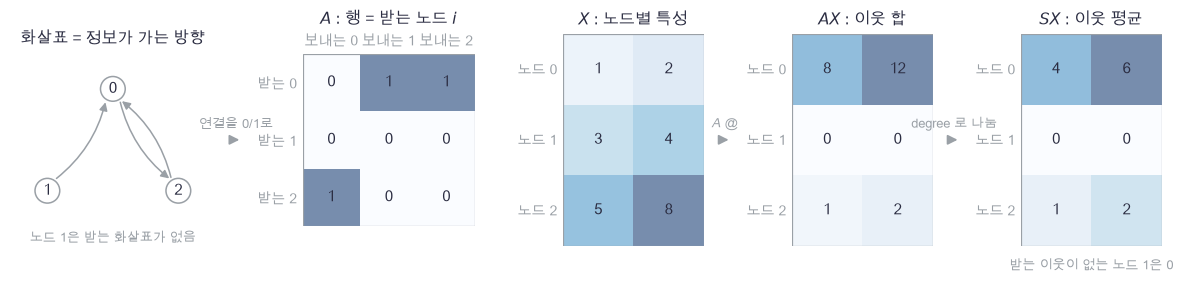

In [4]:
plot_aggregation(agg_A, tri_positions, agg_X, agg_sum, agg_mean)

🔍 **확인** · 노드 0의 행은 `[0, 1, 1]`이라 1과 2의 특성을 더한 `[8, 12]`를 받고, degree 2로 나누면 평균 `[4, 6]`입니다. 노드 1의 행은 모두 0이라 합도 평균도 0입니다. 노드 2는 0에게서만 받아 합과 평균이 같습니다.
화살표 방향과 행렬의 행·열을 맞추는 것이 이 절의 전부입니다. 아래 구현은 배치 축을 포함한 집계 행렬과, 검산용 반복문 집계입니다.

In [5]:
def aggregation_matrix(A, mode="sum"):
    """집계 행렬 S: 합이면 A 그대로, 평균이면 각 행을 degree로 나눈 것. A: (B, M, M) 0/1 → S: (B, M, M)."""
    assert mode in ("sum", "mean"), "mode는 sum 또는 mean"
    assert A.ndim == 3, "인접 행렬은 배치 축을 포함한 (B, M, M)이어야 합니다"
    assert A.shape[-1] == A.shape[-2], "인접 행렬은 정사각이어야 합니다"
    assert np.all((A == 0) | (A == 1)), "이 구현의 입력 인접 행렬은 0/1입니다"
    if mode == "sum":
        return A
    degree = A.sum(axis=-1, keepdims=True)                  # (B, M, 1): 받는 이웃 수
    return A / np.maximum(degree, 1)                        # 이웃이 없는 행은 0으로 남음


def aggregate_loops(X, S):
    """집계를 삼중 반복문으로 (검산용): messages[b, i] = Σ_j S[b, i, j] X[b, j]. X: (B, M, D), S: (B, M, M) → (B, M, D)."""
    B, M, D = X.shape
    messages = np.zeros_like(X)
    for b in range(B):
        for i in range(M):                                  # 받는 노드
            for j in range(M):                              # 보내는 노드
                messages[b, i] += S[b, i, j] * X[b, j]
    return messages

In [6]:
# 쓰는 것: agg_A, agg_S, agg_mean (1절 손계산 셀)
A_hand = np.array([[[0., 1., 1.], [0., 0., 0.], [1., 0., 0.]]])   # (1, 3, 3): 손계산 그래프에 배치 축을 붙임
X_hand = np.array([[[1., 2.], [3., 4.], [5., 8.]]])              # (1, 3, 2)
sum_messages = A_hand @ X_hand                                   # (1, 3, 2): 이웃 합
mean_messages = aggregation_matrix(A_hand, "mean") @ X_hand      # (1, 3, 2): 이웃 평균
np.testing.assert_allclose(sum_messages[0], [[8, 12], [0, 0], [1, 2]])    # 검산: 손계산 이웃 합
np.testing.assert_allclose(mean_messages[0], [[4, 6], [0, 0], [1, 2]])    # 검산: 손계산 이웃 평균
np.testing.assert_allclose(aggregate_loops(X_hand, A_hand), sum_messages) # 검산: 반복문 = 행렬곱
print("노드 0은 노드 1·2에서 받고, 노드 1은 받는 이웃이 없습니다")
np.testing.assert_allclose(aggregation_matrix(agg_A[None], "mean")[0], agg_S)     # 검산: 위 그림의 S
np.testing.assert_allclose(mean_messages[0], agg_mean)                            # 검산: 위 그림의 이웃 평균

노드 0은 노드 1·2에서 받고, 노드 1은 받는 이웃이 없습니다


🔍 **확인** · 반복문 집계와 행렬곱 `A @ X`가 같고, 손계산의 이웃 합·평균과도 같습니다.

### ✏️ 연습 1 · 쪽지의 방향을 행렬에 적기

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.** `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요. 아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

"j가 i에게 보낸다"는 edge 목록 `edges`(각 원소가 `(sender, receiver)`)로 인접 행렬 `A` `(M, M)`을 채우고, 행렬곱 한 번으로 이웃 합 `messages` `(M, D)`를 내는 줄을 채우세요. 받는 노드가 행, 보내는 노드가 열입니다. 방향을 뒤집으면 노드 1이 이웃 합을 받게 되어 검사가 잡습니다.

In [7]:
def exercise_edge_direction(edges, X):
    """연습 1: edge 목록으로 인접 행렬을 만들고 이웃 합까지. edges: (보내는 j, 받는 i) 쌍의 목록, X: (M, D) → (A: (M, M), messages: (M, D))."""
    M = X.shape[0]
    A = np.zeros((M, M))                                    # (M, M): 행 = 받는 노드, 열 = 보내는 노드. 0으로 채워 두었으니 edge 자리만 1로 바꿉니다
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: edge (sender, receiver)마다 A의 받는 행·보내는 열 자리에 1을 넣고, 이어서 행렬곱 한 번으로 이웃 합 messages (M, D)
    ### 힌트: 1절의 "A_ij = 1은 j가 i에게 보낸다"입니다. for sender, receiver in edges: 안은 한 줄이고, 이웃 합은 1절 손계산 셀의 agg_sum 줄과 같습니다.
    raise NotImplementedError
    return A, messages

In [8]:
def check_edge_direction(candidate):
    """1절 3노드 그래프의 edge 세 개로 인접 행렬과 이웃 합을 손계산과 대조합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: agg_A, agg_sum (1절 손계산 셀)
    example_edges = [(1, 0), (2, 0), (0, 2)]                # (보내는 j, 받는 i): 1→0, 2→0, 0→2
    example_X = np.array([[1., 2.], [3., 4.], [5., 8.]])     # (3, 2)
    A, messages = candidate(example_edges, example_X)
    assert A.shape == (3, 3), f"A는 (M, M) = (3, 3)이어야 하는데 {A.shape}입니다"
    np.testing.assert_array_equal(A, [[0, 1, 1], [0, 0, 0], [1, 0, 0]])   # 검산: 행 0에 1·2가, 행 2에 0이 보냄. 행 1은 받는 것이 없음
    np.testing.assert_array_equal(A.sum(axis=1), [2, 0, 1])              # 검산: 받는 이웃 수 degree
    np.testing.assert_allclose(messages, [[8., 12.], [0., 0.], [1., 2.]])  # 검산: 노드 0은 [3, 4] + [5, 8], 노드 2는 [1, 2]
    np.testing.assert_array_equal(A, agg_A)                 # 검산: 1절 손계산 셀의 agg_A
    np.testing.assert_allclose(messages, agg_sum)           # 검산: 1절 손계산 셀의 이웃 합
    print("인접 행렬의 방향: 손계산과 일치합니다.")

run_check(check_edge_direction, exercise_edge_direction, hint="A[receiver, sender] = 1. (반복문 안), messages = A @ X")

☐ exercise_edge_direction: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: A[receiver, sender] = 1. (반복문 안), messages = A @ X


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
for sender, receiver in edges:
    A[receiver, sender] = 1.
messages = A @ X
```

</details>

## 🔑 2. 한 층의 message passing과 backward

**이 절에서 가져갈 것:** 노드마다 자기 특성은 $W_s$로, 이웃 합은 $W_n$으로 옮겨 더한 뒤 tanh를 지납니다. 모든 노드가 같은 $W_s, W_n, b$를 쓰므로 파라미터 수는 노드 수와 무관합니다. backward에서 이웃 경로는 **$S$의 전치**를 타고 보낸 노드로 돌아갑니다.

> **용어**
>
> - **message passing**: 이웃의 특성을 모아(집계) 자기 특성과 함께 갱신하는 한 층. 05번의 커널, 06번의 $W_h$처럼 모든 노드가 같은 가중치를 씁니다.
> - **self 경로·neighbor 경로**: 자기 특성 $x_i$가 지나는 $W_s$와 이웃 합 $m_i$가 지나는 $W_n$. 노드 번호별로 다른 가중치는 두지 않습니다.

모든 노드가 같은 두 가중치를 사용하게 만듭니다.
$$Z=XW_s+(SX)W_n+b,\qquad H=\tanh(Z).$$
$W_s,W_n:(D,H)$입니다. self 경로와 neighbor 경로에 다른 가중치를 쓰되, 노드 번호에 따라 별도 가중치를 만들지 않습니다. 파라미터 수는 $2DH+H$로 노드 수에 의존하지 않습니다.

상류 기울기를 $dH$라 두면 $dZ=dH\odot(1-H^2)$입니다. $R=SX$라 쓰고
$$dW_s=\sum_b X_b^TdZ_b,\quad dW_n=\sum_bR_b^TdZ_b,\quad db=\sum_{b,i}dZ_{b,i},$$
$$dR=dZW_n^T,\qquad dX=dZW_s^T+S^TdR.$$

$dX$의 첫 항은 자기 경로로 돌아온 몫, 둘째 항은 "내가 보낸 이웃들이 받은 기울기"를 $S^\top$으로 모아 온 몫입니다.

forward에서는 보내는 j를 모아 받는 i에 합했습니다. backward에서는 받는 i에서 돌아온 기여를 보내는 j에 누적하므로 **S의 전치**가 등장합니다. 평균 집계의 S는 무방향 A에서 만들어도 degree가 다르면 대칭이 아닐 수 있습니다.

A는 이번 모델에서 주어진 고정 연결입니다. 이산 edge의 추가·삭제를 미분하거나 A 자체를 학습하지 않습니다.

아래는 1절 그래프의 노드 0을 작은 가중치로 손계산한 것입니다.

> **코드**
>
> - `X.reshape(-1, D).T @ dZ.reshape(-1, width)`: 배치·노드 두 축을 하나로 펼친 뒤 행렬곱. 모든 노드가 공유하는 W의 기울기를 배치와 노드에서 합한 것입니다(08·09번과 같은 꼴). `dZ.sum(axis=(0, 1))`은 같은 두 축의 합이라 db입니다.
> - `S.swapaxes(-1, -2) @ dmessages`: 배치를 두고 마지막 두 축을 뒤집은 Sᵀ. 받는 노드로 돌아온 기울기를 보낸 노드에 모읍니다.
> - `[("X", X, dX)] + [(k, v, grads[k]) for k, v in p.items()]`: (이름, 원본, 기울기) 세 쌍의 목록을 이어 붙여 검사할 배열 넷을 한 반복문으로 돌립니다.

In [9]:
# 쓰는 것: agg_A, agg_X (1절 손계산 셀)
layer_Ws = np.array([[0.5, -0.5, 1.0], [0.0, 1.0, 0.5]])           # (D=2, H=3): self 경로
layer_Wn = np.array([[0.2, 0.1, -0.3], [0.1, -0.2, 0.4]])          # (D=2, H=3): neighbor 경로
layer_b = np.array([0.1, 0.0, -0.1])                                # (3,)
layer_m = agg_A @ agg_X                                            # (3, 2): 합 집계 (S = A)
layer_zs = agg_X @ layer_Ws                                        # (3, 3): 자기 특성의 기여 XW_s
layer_zn = layer_m @ layer_Wn                                      # (3, 3): 이웃 합의 기여 (SX)W_n
layer_Z = layer_zs + layer_zn + layer_b                            # (3, 3): Z
layer_H = np.tanh(layer_Z)                                         # (3, 3): H
print("노드 0: x·Ws =", layer_zs[0], "· m·Wn =", layer_zn[0], "· z =", layer_Z[0], "· h =", layer_H[0].round(3))

노드 0: x·Ws = [0.5 1.5 2. ] · m·Wn = [ 2.8 -1.6  2.4] · z = [ 3.4 -0.1  4.3] · h = [ 0.998 -0.1    1.   ]


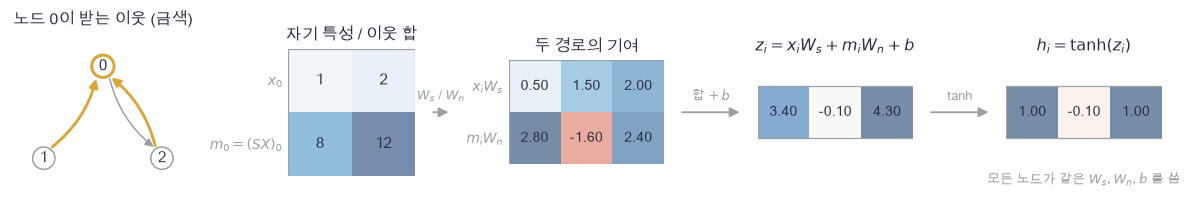

In [10]:
plot_layer_paths(agg_A, tri_positions, 0, agg_X[0], layer_m[0], layer_zs[0], layer_zn[0], layer_Z[0], layer_H[0], [(0, 1), (0, 2)])

🔍 **확인** · 노드 0의 새 표현은 자기 특성 `[1, 2]`를 $W_s$로 옮긴 것과 이웃 합 `[8, 12]`를 $W_n$으로 옮긴 것의 합에 $b$를 더해 tanh를 지난 값입니다. 노드 1은 이웃 합이 0이라 self 경로만 남고, 노드 2도 같은 $W_s, W_n$을 씁니다.
backward에서 노드 0이 받은 기울기는 $W_n^\top$을 거쳐 $S^\top$으로 노드 1·2에게 돌아갑니다. 노드 1이 "받는 이웃이 없다"는 것과 "보내는 곳이 없다"는 것은 다른 일입니다. 아래 검사기의 그래프에는 두 경우가 모두 들어 있습니다.

In [11]:
def gnn_layer_forward(X, A, p, mode="sum"):
    """한 층의 message passing: Z = XW_s + (SX)W_n + b, H = tanh(Z). 모든 노드가 같은 W_s, W_n, b를 씁니다.
    X: (B, M, D), A: (B, M, M) 0/1, p: {"Ws": (D, H), "Wn": (D, H), "b": (H,)} → (H: (B, M, H), cache: (X, S, SX, H))."""
    # 쓰는 것: aggregation_matrix (1절)
    S = aggregation_matrix(A, mode)                         # (B, M, M): 합이면 A, 평균이면 행을 degree로 나눈 것
    messages = S @ X                                        # (B, M, D): 노드마다 이웃 집계 R = SX
    Z = X @ p["Ws"] + messages @ p["Wn"] + p["b"]           # (B, M, H): self 경로 + neighbor 경로 + 편향
    H = np.tanh(Z)
    return H, (X, S, messages, H)


def gnn_layer_backward(dH, cache, p):
    """한 층 backward: dZ = dH⊙(1−H²), dW_s = Σ XᵀdZ, dW_n = Σ RᵀdZ, db = Σ dZ, dX = dZ W_sᵀ + Sᵀ(dZ W_nᵀ).
    dH: (B, M, H), cache: gnn_layer_forward의 것 → (dX: (B, M, D), grads: {"Ws", "Wn", "b"})."""
    X, S, messages, H = cache
    dZ = dH * (1 - H ** 2)                                  # (B, M, H): tanh 도함수를 곱함
    D, width = X.shape[-1], H.shape[-1]
    grads = {"Ws": X.reshape(-1, D).T @ dZ.reshape(-1, width),           # dW_s = Σ_b X_bᵀ dZ_b (배치·노드 합)
             "Wn": messages.reshape(-1, D).T @ dZ.reshape(-1, width),    # dW_n = Σ_b R_bᵀ dZ_b
             "b": dZ.sum(axis=(0, 1))}                                   # db = Σ_{b,i} dZ
    dmessages = dZ @ p["Wn"].T                              # (B, M, D): dR = dZ W_nᵀ. 받는 노드에 도착한 이웃 경로 기울기
    dX = dZ @ p["Ws"].T + S.swapaxes(-1, -2) @ dmessages    # (B, M, D): self 경로 + Sᵀ로 보낸 노드에 모은 neighbor 경로
    return dX, grads

In [12]:
def check_gnn_layer(candidate):
    """합·평균 집계, 비대칭 A, 받는 이웃만 없는 노드, 고립 노드가 든 배치에서 X와 세 파라미터의 기울기를 중심차분과 대조합니다. → 상대오차 사전."""
    rng = np.random.default_rng(101)
    errors = {}
    A = np.array([[[0., 1., 1., 0.], [0., 0., 0., 0.], [1., 0., 0., 0.], [0., 0., 0., 0.]],     # 그래프 0: 1절 그래프 + 고립 노드 3
                  [[0., 0., 1., 0.], [1., 0., 0., 0.], [0., 1., 0., 0.], [0., 0., 0., 0.]]])    # 그래프 1: 0←2, 1←0, 2←1 순환 + 고립 노드 3
    for mode in ["sum", "mean"]:
        X = rng.normal(size=(2, 4, 2))                      # (B, M, D)
        p = {"Ws": rng.normal(size=(2, 3)) * 0.3, "Wn": rng.normal(size=(2, 3)) * 0.3,
             "b": rng.normal(size=3) * 0.2}
        H, cache = gnn_layer_forward(X, A, p, mode)
        G = rng.normal(size=H.shape)                        # 임의의 상류 기울기
        dX, grads = candidate(G, cache, p)

        def scalar():
            """검사기용: 스칼라 L = Σ H ⊙ G (이번 mode)."""
            return float(np.sum(gnn_layer_forward(X, A, p, mode)[0] * G))

        entries = [("X", X, dX)] + [(k, v, grads[k]) for k, v in p.items()]   # (이름, 원본, 기울기)
        for name, value, grad in entries:
            error = rel_error(grad, numerical_gradient(scalar, value))   # value를 흔들어 잰 중심차분과 비교
            assert np.isfinite(error), (mode, name, error)
            assert error < 2e-6, (mode, name, error)        # 통과하지 못하면 (mode, 이름, 오차)를 메시지로 (7절의 오답 검출이 이것을 출력)
            errors[f"{mode}/{name}"] = error
    return errors

In [13]:
# 쓰는 것: agg_A, agg_X (1절 손계산 셀) · layer_Ws, layer_Wn, layer_b, layer_H (2절 손계산 셀)
gnn_layer_errors = check_gnn_layer(gnn_layer_backward)
print("합·평균, 방향·고립 노드의 최대 미분 상대오차:", max(gnn_layer_errors.values()))
layer_H_fn, _ = gnn_layer_forward(agg_X[None], agg_A[None], {"Ws": layer_Ws, "Wn": layer_Wn, "b": layer_b}, "sum")   # 손계산 설정으로
np.testing.assert_allclose(layer_H_fn[0], layer_H)                                # 검산: 위 그림의 손계산과 같음

합·평균, 방향·고립 노드의 최대 미분 상대오차: 1.9854066525716172e-10


🔍 **확인** · 합·평균 집계, 비대칭 $A$, 받는 이웃만 없는 노드, 들어오고 나가는 연결이 모두 없는 고립 노드에서 $X$와 세 파라미터의 미분이 중심차분과 맞습니다. 손계산 노드 0의 $h$도 같습니다.

### ✏️ 연습 2 · 나눠 쓰는 가중치의 기울기

노드 특성 `X`와 이웃 집계 `messages`(둘 다 `(B, M, D)`), 활성 전 값의 기울기 `dZ` `(B, M, H)`에서 공유 가중치의 기울기 `dWs`, `dWn` `(D, H)` 두 줄을 채우세요. 모든 노드가 같은 $W_s, W_n$을 쓰므로 배치와 노드 축을 모두 더해야 합니다. `db`는 미리 써 두었습니다.

In [14]:
def exercise_shared_grads(X, messages, dZ):
    """연습 2: 공유 파라미터의 기울기. X, messages: (B, M, D), dZ: (B, M, H) → (dWs, dWn: (D, H), db: (H,))."""
    assert X.shape == messages.shape, "X와 이웃 집계 messages는 같은 (B, M, D)여야 합니다"
    D, width = X.shape[-1], dZ.shape[-1]
    db = dZ.sum(axis=(0, 1))                                # (H,): 배치·노드 축을 모두 더한 편향 기울기
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 모든 노드가 같은 W_s, W_n을 쓰므로 배치·노드를 합한 dWs = Σ XᵀdZ, dWn = Σ RᵀdZ (R = messages), 둘 다 (D, H)
    ### 힌트: 2절 gnn_layer_backward의 grads 두 줄입니다. 배치·노드 두 축을 하나로 펼친 뒤 전치 행렬곱이며, 그 관용구는 2절 코드 상자에 풀이가 있습니다 (수식의 폭 H가 변수 width입니다).
    raise NotImplementedError
    return dWs, dWn, db

In [15]:
def check_shared_grads(candidate):
    """노드 2개 손계산 하나와 본문 gnn_layer_backward의 grads로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: agg_A (1절 손계산 셀) · gnn_layer_forward, gnn_layer_backward (2절)
    example_X = np.array([[[1., 2.], [3., 4.]]])            # (B=1, M=2, D=2)
    example_R = np.array([[[3., 4.], [0., 0.]]])            # (1, 2, 2): 노드 0만 노드 1에게서 받은 이웃 합
    example_dZ = np.array([[[1.], [2.]]])                   # (1, 2, H=1)
    dWs, dWn, db = candidate(example_X, example_R, example_dZ)
    assert dWs.shape == (2, 1), f"dWs는 (D, H) = (2, 1)이어야 하는데 {dWs.shape}입니다"
    np.testing.assert_allclose(dWs, [[7.], [10.]])          # 검산: 노드 0과 1의 xᵀdz를 더함 [1·1 + 3·2, 2·1 + 4·2]
    np.testing.assert_allclose(dWn, [[3.], [4.]])           # 검산: [3·1 + 0·2, 4·1 + 0·2]
    np.testing.assert_allclose(db, [3.])                    # 검산: 1 + 2
    rng = np.random.default_rng(110)
    A_c = np.stack([agg_A, agg_A.T])                        # (2, 3, 3): 1절 그래프와 화살표를 뒤집은 그래프
    X_c = rng.normal(size=(2, 3, 2))
    p_c = {"Ws": rng.normal(size=(2, 3)), "Wn": rng.normal(size=(2, 3)), "b": np.zeros(3)}
    H_c, cache_c = gnn_layer_forward(X_c, A_c, p_c, "mean")
    dH_c = rng.normal(size=H_c.shape)
    _, grads_c = gnn_layer_backward(dH_c, cache_c, p_c)
    dWs_c, dWn_c, _ = candidate(X_c, cache_c[2], dH_c * (1 - H_c ** 2))   # 캐시의 이웃 집계 R과 tanh 도함수를 곱한 dZ
    np.testing.assert_allclose(dWs_c, grads_c["Ws"])        # 검산: 본문 gnn_layer_backward의 dWs와 같음
    np.testing.assert_allclose(dWn_c, grads_c["Wn"])        # 검산: dWn도 같음
    print("공유 파라미터의 기울기: 손계산·gnn_layer_backward와 일치합니다.")

run_check(check_shared_grads, exercise_shared_grads, hint="dWs = X.reshape(-1, D).T @ dZ.reshape(-1, width), dWn = messages.reshape(-1, D).T @ dZ.reshape(-1, width)")

☐ exercise_shared_grads: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dWs = X.reshape(-1, D).T @ dZ.reshape(-1, width), dWn = messages.reshape(-1, D).T @ dZ.reshape(-1, width)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dWs = X.reshape(-1, D).T @ dZ.reshape(-1, width)
dWn = messages.reshape(-1, D).T @ dZ.reshape(-1, width)
```

</details>

## 🔑 3. 층을 쌓으면 읽는 범위가 넓어집니다

**이 절에서 가져갈 것:** 한 층은 자기와 1-hop 이웃을, 두 층은 최대 2-hop까지를 읽을 수 있습니다. 그래프 하나의 답을 내려면 노드 표현을 평균낸 readout에 head를 붙이고, backward에서 각 노드는 같은 $dr/M$을 받습니다.

> **용어**
>
> - **hop**: edge를 한 번 건너는 것. $k$층을 쌓으면 최대 $k$-hop 거리의 노드 정보가 닿을 수 있습니다.
> - **readout**: 노드 표현 $M$개를 그래프 하나의 벡터로 줄이는 것. 여기서는 평균 $r=\frac1M\sum_iH_i$.

한 층은 self와 1-hop 이웃을 읽습니다. 두 층은 최대 2-hop까지의 정보를 받을 수 있습니다. 모든 멀리 떨어진 노드의 정보를 즉시 볼 수 있는 것은 아닙니다. `(I+A)^2`의 양수 위치는 두 번의 self/이웃 전달로 도달하는 쌍입니다. 실제 학습된 가중치에 따라 기여가 0이 될 수도 있어, 이는 **가능한 연결 범위**입니다.

노드 분류는 각 $H_i$에 head를 붙입니다. 그래프 분류는 노드 전체를 모은 readout이 필요합니다. 여기서는 평균
$$r=\frac1M\sum_iH_i,\quad logits=rW_o+b_o$$
를 사용합니다. backward에서 각 노드는 같은 $dr/M$을 받습니다. 노드 수가 다른 그래프를 padding해 한 배치로 합치면 유효 노드만 합하고 실제 노드 수로 나눠야 합니다. 이번 구현은 한 배치 안의 M이 같고 padding은 없습니다.

아래는 일렬로 연결한 5노드에서 가운데 노드가 받을 수 있는 범위입니다.

> **코드**
>
> - `hop_A[i, i + 1] = hop_A[i + 1, i] = 1`: 양방향 edge를 한 줄에. `A[0, 1:] = A[1:, 0] = 1`은 노드 0과 나머지 전부를 잇는 별입니다.
> - `(np.eye(5) + hop_A) > 0`: 자기(단위행렬)와 1-hop을 합친 뒤 양수인 자리만 True. 두 번 곱하면 2-hop까지 닿는 쌍입니다. `np.flatnonzero`는 True인 번호들.
> - `np.broadcast_to((dreadout / M)[:, None, :], shape)`: `(B, H)`에 노드 축을 끼워 `(B, 1, H)`로 만들고 M개 노드에 같은 값을 늘립니다. 평균의 backward입니다.
> - `[{…} for din in [D, H]]`: 입력 폭이 D인 첫 층과 H인 둘째 층의 파라미터 사전 둘을 목록으로.
> - `[*probe_layers, probe_head]`: 층 목록을 펼치고 head를 뒤에 붙인 목록. `enumerate(zip(…))`로 번호·파라미터·기울기를 함께 돕니다.

In [16]:
hop_A = np.zeros((5, 5))                                             # (5, 5): 사슬의 인접 행렬
for i in range(4):
    hop_A[i, i + 1] = hop_A[i + 1, i] = 1                            # 사슬: 0-1-2-3-4 (양방향)
hop_one = (np.eye(5) + hop_A) > 0                                    # (5, 5): 1층: 자기 + 1-hop
hop_two = ((np.eye(5) + hop_A) @ (np.eye(5) + hop_A)) > 0            # (5, 5): 2층: 최대 2-hop
print("노드 2가 받는 범위 · 1층:", np.flatnonzero(hop_one[2]), "· 2층:", np.flatnonzero(hop_two[2]))

노드 2가 받는 범위 · 1층: [1 2 3] · 2층: [0 1 2 3 4]


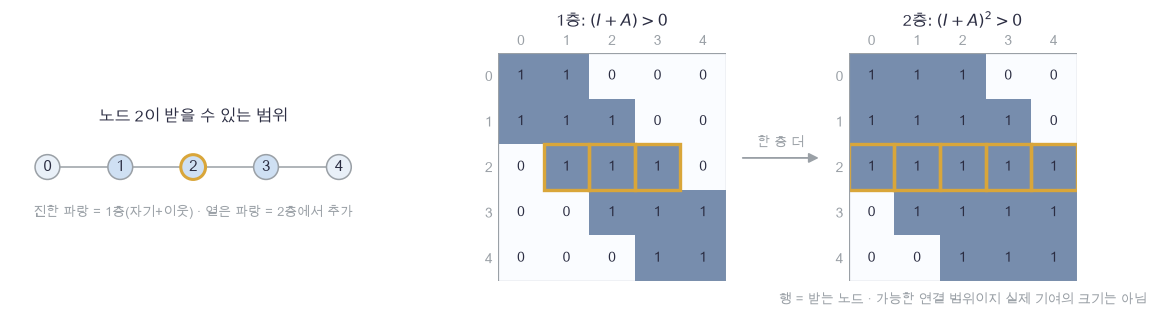

In [17]:
plot_hops(hop_A, line5_positions, 2, hop_one, hop_two)

🔍 **확인** · 한 층 뒤 노드 2는 자기와 1·3만 읽을 수 있고, 두 층 뒤에는 0·4까지 닿습니다. 표의 금색 칸이 그 범위입니다. 끝 노드 0은 두 층 뒤에도 2까지만 닿습니다.
아래 구현은 사슬·별 인접 행렬, 2층 + 평균 readout + head의 forward·backward, 초기화입니다.

In [18]:
def path_adjacency(M):
    """사슬 그래프 0-1-…-(M−1)의 인접 행렬 (M, M), 양방향."""
    A = np.zeros((M, M))
    for i in range(M - 1):
        A[i, i + 1] = A[i + 1, i] = 1
    return A


def star_adjacency(M):
    """별 그래프의 인접 행렬 (M, M): 노드 0이 나머지 M−1개와 양방향으로 연결."""
    A = np.zeros((M, M))
    A[0, 1:] = A[1:, 0] = 1
    return A

In [19]:
def graph_forward(X, A, layers, head, mode="sum"):
    """그래프 분류 forward: 층 두 개 → 노드 평균 readout r → logits = rW_o + b_o.
    X: (B, M, D), A: (B, M, M), layers: 층 파라미터 사전 둘, head: {"W": (H, 2), "b": (2,)} → (logits: (B, 2), cache)."""
    # 쓰는 것: gnn_layer_forward (2절)
    H1, cache1 = gnn_layer_forward(X, A, layers[0], mode)
    H2, cache2 = gnn_layer_forward(H1, A, layers[1], mode)
    readout = H2.mean(axis=1)                               # (B, H): 노드 축의 평균
    return readout @ head["W"] + head["b"], (cache1, cache2, H2.shape, readout)

In [20]:
def graph_backward(dlogits, cache, layers, head, layer_backward_fn=gnn_layer_backward):
    """그래프 분류 backward: head → 평균 readout(노드마다 dr/M) → 둘째 층 → 첫 층.
    dlogits: (B, 2), cache: graph_forward의 것 → (dX: (B, M, D), [층 0 기울기, 층 1 기울기], head 기울기)."""
    # 쓰는 것: gnn_layer_backward (2절)
    cache1, cache2, shape, readout = cache
    dhead = {"W": readout.T @ dlogits, "b": dlogits.sum(axis=0)}   # head의 affine backward
    dreadout = dlogits @ head["W"].T                        # (B, H)
    dH2 = np.broadcast_to((dreadout / shape[1])[:, None, :], shape)   # (B, M, H): 각 노드가 같은 dr/M을 받음
    dH1, grad2 = layer_backward_fn(dH2, cache2, layers[1])
    dX, grad1 = layer_backward_fn(dH1, cache1, layers[0])
    return dX, [grad1, grad2], dhead

In [21]:
def init_graph(D=1, H=8, seed=102):
    """층 두 개(입력 D → H → H)와 head(H → 2)의 파라미터를 난수로. → (layers: 사전 둘의 목록, head: 사전)."""
    rng = np.random.default_rng(seed)
    layers = [{"Ws": rng.normal(size=(din, H)) * 0.5 / np.sqrt(din),
               "Wn": rng.normal(size=(din, H)) * 0.2 / np.sqrt(din), "b": np.zeros(H)} for din in [D, H]]   # 층마다 입력 폭이 다름
    head = {"W": rng.normal(size=(H, 2)) / np.sqrt(H), "b": np.zeros(2)}
    return layers, head

In [22]:
# 쓰는 것: A_hand (1절 검산 셀) · hop_A, hop_two (3절 hop 셀) · path_adjacency, graph_forward, graph_backward, init_graph (3절)
path5 = path_adjacency(5)
one_hop = (np.eye(5) + path5) > 0
two_hop = ((np.eye(5) + path5) @ (np.eye(5) + path5)) > 0
# 그래프 분류 전체의 입력·모든 파라미터도 독립적인 스칼라와 비교합니다.
probe_X = np.random.default_rng(103).normal(size=(2, 3, 2))          # (B, M, D)
probe_A = np.stack([path_adjacency(3), A_hand[0]])                   # (2, 3, 3): 사슬과 1절의 방향 그래프
probe_layers, probe_head = init_graph(2, 3, 104)
probe_logits, probe_cache = graph_forward(probe_X, probe_A, probe_layers, probe_head)
G = np.random.default_rng(105).normal(size=probe_logits.shape)       # 임의의 상류 기울기
dX, d_layers, d_head = graph_backward(G, probe_cache, probe_layers, probe_head)


def graph_scalar():
    """검사기용: 스칼라 L = Σ logits ⊙ G."""
    return float(np.sum(graph_forward(probe_X, probe_A, probe_layers, probe_head)[0] * G))


graph_errors = {"X": rel_error(dX, numerical_gradient(graph_scalar, probe_X))}
for i, (params, grads) in enumerate(zip([*probe_layers, probe_head], [*d_layers, d_head])):   # 층 0, 층 1, head 차례로
    for k, value in params.items():
        graph_errors[f"{i}/{k}"] = rel_error(grads[k], numerical_gradient(graph_scalar, value))
assert max(graph_errors.values()) < 2e-6, "입력과 모든 파라미터의 상대오차가 2e−6 아래여야 합니다"
print("2층·readout·head 전체 최대 미분 상대오차:", max(graph_errors.values()))
np.testing.assert_array_equal(path_adjacency(5), hop_A)     # 검산: 위 그림의 사슬과 같음
np.testing.assert_array_equal(two_hop, hop_two)             # 검산: 2-hop 범위도 같음

2층·readout·head 전체 최대 미분 상대오차: 5.576446392942628e-10


🔍 **확인** · 2층·readout·head 전체의 입력과 모든 파라미터 미분이 중심차분과 맞습니다. 검사의 배치에는 사슬과 1절의 방향 그래프가 함께 들어 있습니다.

### ✏️ 연습 3 · 두 층이면 어디까지 닿나

인접 행렬 `A` `(M, M)`에서 한 층 뒤에 닿을 수 있는 쌍 `one_hop`과 두 층 뒤에 닿을 수 있는 쌍 `two_hop`(둘 다 `(M, M)` True/False)을 만드는 두 줄을 채우세요. 자기 자신은 self 경로로 항상 닿으므로 단위행렬 `identity`를 더한 뒤 양수인 자리를 봅니다.

In [23]:
def exercise_hop_range(A):
    """연습 3: 층을 쌓을 때 닿을 수 있는 범위. A: (M, M) 0/1 → (one_hop, two_hop: (M, M) bool). [i, j]가 True면 i가 j의 정보를 받을 수 있음."""
    assert A.shape[0] == A.shape[1], "A는 정사각 (M, M)이어야 합니다"
    identity = np.eye(A.shape[0])                           # (M, M): 자기 자신 = self 경로
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 한 층 뒤 범위 one_hop = (자기 + 1-hop)이 양수인 자리, 두 층 뒤 범위 two_hop = (자기 + 1-hop)을 두 번 곱해 양수인 자리
    ### 힌트: 3절 hop 셀의 hop_one, hop_two 두 줄입니다. (I + A)의 양수 자리가 한 층, (I + A)(I + A)의 양수 자리가 두 층입니다 (수식의 I가 identity).
    raise NotImplementedError
    return one_hop, two_hop

In [24]:
def check_hop_range(candidate):
    """5노드 사슬과 4노드 별에서 닿는 범위를 손계산과 대조합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: hop_one, hop_two (3절 hop 셀)
    chain = np.array([[0., 1., 0., 0., 0.], [1., 0., 1., 0., 0.], [0., 1., 0., 1., 0.],
                      [0., 0., 1., 0., 1.], [0., 0., 0., 1., 0.]])   # (5, 5): 사슬 0-1-2-3-4
    one_hop, two_hop = candidate(chain)
    assert one_hop.dtype == bool, f"닿는 범위는 True/False 배열이어야 하는데 dtype이 {one_hop.dtype}입니다"
    np.testing.assert_array_equal(np.flatnonzero(one_hop[2]), [1, 2, 3])       # 검산: 가운데 노드는 한 층 뒤 자기와 양옆
    np.testing.assert_array_equal(np.flatnonzero(two_hop[2]), [0, 1, 2, 3, 4]) # 검산: 두 층 뒤에는 끝까지
    np.testing.assert_array_equal(np.flatnonzero(two_hop[0]), [0, 1, 2])       # 검산: 끝 노드 0은 두 층 뒤에도 2까지
    np.testing.assert_array_equal(one_hop, hop_one)                            # 검산: 3절 hop 셀의 1층 범위
    np.testing.assert_array_equal(two_hop, hop_two)                            # 검산: 3절 hop 셀의 2층 범위
    star = np.array([[0., 1., 1., 1.], [1., 0., 0., 0.], [1., 0., 0., 0.], [1., 0., 0., 0.]])   # (4, 4): 노드 0이 가운데인 별
    one_star, two_star = candidate(star)
    np.testing.assert_array_equal(np.flatnonzero(one_star[1]), [0, 1])         # 검산: 잎 노드 1은 한 층 뒤 가운데 0만
    assert two_star.all(), "별은 두 층이면 모든 쌍이 닿아야 합니다 (잎 → 가운데 → 다른 잎)"
    print("층 수와 닿는 범위: 손계산과 일치합니다.")

run_check(check_hop_range, exercise_hop_range, hint="one_hop = (identity + A) > 0, two_hop = ((identity + A) @ (identity + A)) > 0")

☐ exercise_hop_range: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: one_hop = (identity + A) > 0, two_hop = ((identity + A) @ (identity + A)) > 0


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
one_hop = (identity + A) > 0
two_hop = ((identity + A) @ (identity + A)) > 0
```

</details>

## 🔑 4. 완성 학습: 사슬 모양과 별 모양 그래프 분류

**이 절에서 가져갈 것:** 노드 수·edge 수·평균 degree가 같은 두 그래프도 이웃 구성이 다르면 비선형 층을 거친 노드 표현이 달라지고, 그 평균으로 분류할 수 있습니다. 노드 특성은 거의 상수라 **연결의 형태**만이 정보입니다.

> **용어** · **사슬(path)·별(star) 그래프**: 사슬은 0-1-2-3-4-5로 일렬 연결, 별은 노드 0이 나머지 다섯과 연결. 둘 다 edge 5개이고 평균 degree가 같습니다.

두 그래프는 노드 6개·edge 5개로 같습니다. 초기 특성은 모든 노드에서 1에 작은 잡음을 더한 값입니다. 연결의 형태를 읽어야 합니다. 학습 128개·검증 64개는 두 기본 그래프를 독립적으로 노드 순열·잡음으로 변형합니다. 이는 **두 모양의 새 순열·잡음**에 대한 평가이며, 임의의 새로운 그래프 종류에 대한 성능은 아닙니다.

합 집계→tanh를 두 번 거쳐 평균 readout으로 분류합니다. 잡음을 빼고 초기 특성을 모두 같은 값으로 고정하면, 선형으로 한 번 집계한 뒤 바로 평균낼 때 두 그래프의 평균 degree가 같아 구별하지 못합니다. 잡음 특성에서는 이 등식이 항상 성립하지 않으므로 이 조건을 분리해서 생각합니다. 비선형 노드 표현이 degree의 분포와 이웃 구성을 구별할 기회를 만듭니다.

아래는 두 기본 그래프와 노드별 degree입니다.

> **코드**
>
> - `A[permutation][:, permutation]`: 행을 순열로 고른 뒤 열도 같은 순열로. 노드 번호만 바꾼 같은 그래프입니다(5절).
> - `np.vstack([np.zeros(2), …])`: 그림 좌표. 가운데 점 하나 위에 원 위의 점 다섯을 행으로 쌓습니다.
> - `params_all = [*layers, head]`: 층 둘과 head를 한 목록에. `zip(params_all, [*d_layers, d_head], states)`로 파라미터·기울기·Adam 상태를 짝지어 갱신합니다.
> - `sum(v.size for p in params_all for v in p.values())`: 사전마다, 배열마다 원소 수를 더한 파라미터 수(이중 제너레이터).

In [25]:
# 쓰는 것: path_adjacency, star_adjacency (3절)
path6, star6 = path_adjacency(6), star_adjacency(6)                # (6, 6) 둘: 사슬과 별
angles = np.arange(6) * 2 * np.pi / 6                              # (6,): 원 위의 각도 (그림용)
circle = np.stack([np.cos(angles), np.sin(angles)], axis=1)        # (6, 2): 고리 그림 좌표 (6절)
star_positions = np.vstack([np.zeros(2), np.stack([np.cos(angles[:5] * 6/5), np.sin(angles[:5] * 6/5)], axis=1)])   # (6, 2): 가운데 + 둘레 5
line_positions = np.stack([np.arange(6), np.zeros(6)], axis=1)     # (6, 2): 사슬 그림 좌표
np.testing.assert_allclose(path6.sum(axis=1).mean(), star6.sum(axis=1).mean())   # 검산: 두 그래프의 평균 degree가 같음
print("path degree:", path6.sum(axis=1), "· star degree:", star6.sum(axis=1))
print("두 그래프 평균 degree:", path6.sum(axis=1).mean())

path degree: [1. 2. 2. 2. 2. 1.] · star degree: [5. 1. 1. 1. 1. 1.]
두 그래프 평균 degree: 1.6666666666666667


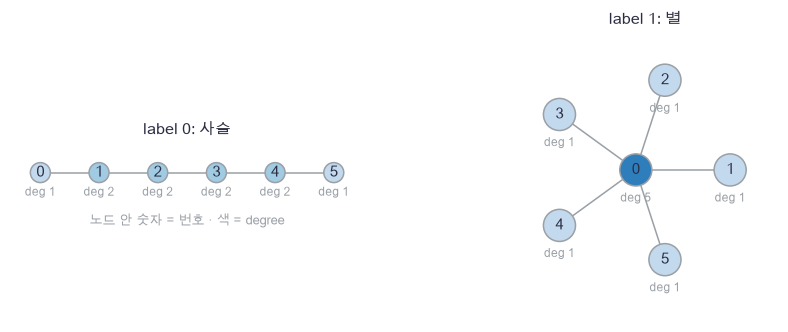

In [26]:
plot_two_graphs([path6, star6], [line_positions, star_positions], [path6.sum(axis=1), star6.sum(axis=1)], ["label 0: 사슬", "label 1: 별"])

🔍 **확인** · 사슬은 degree가 1·2·2·2·2·1, 별은 5·1·1·1·1·1입니다. 합은 둘 다 10이라 평균 degree가 같지만 분포가 다릅니다. 합 집계의 첫 층에서 별의 가운데 노드는 이웃 다섯의 합을, 사슬의 노드는 둘의 합을 받아 표현이 달라집니다.
아래 구현은 데이터 생성(순열·잡음), CE, Adam이고, 이어서 학습합니다.

In [27]:
def graph_data(n, M, seed):
    """사슬(라벨 0)·별(라벨 1) 그래프 n개를 노드 순열과 잡음으로 변형. → (X: (n, M, 1) ≈ 1, A: (n, M, M), y: (n,))."""
    # 쓰는 것: path_adjacency, star_adjacency (3절)
    rng = np.random.default_rng(seed)
    y = np.arange(n) % 2                                    # 라벨을 반씩
    rng.shuffle(y)
    matrices = []
    for label in y:
        A = path_adjacency(M) if label == 0 else star_adjacency(M)
        permutation = rng.permutation(M)                    # 노드 번호를 무작위로 바꿈
        matrices.append(A[permutation][:, permutation])     # 행·열을 함께 재배열
    X = 1 + rng.normal(0, 0.03, size=(n, M, 1))             # 특성은 1에 작은 잡음: 연결의 형태만이 정보
    return X, np.stack(matrices), y

In [28]:
def ce_loss(logits, y):
    """softmax cross-entropy 평균과 logit 기울기 (02번 8절). logits: (N, 2), y: (N,) 정수 → (J: 숫자, dZ: (N, 2) = (P − T)/N)."""
    z = logits - logits.max(axis=-1, keepdims=True)                    # 행마다 최댓값을 빼 지수가 넘치지 않게
    logp = z - np.log(np.exp(z).sum(axis=-1, keepdims=True))           # (N, 2): log softmax
    grad = np.exp(logp)                                                # (N, 2): P
    grad[np.arange(len(y)), y] -= 1                                    # 정답 자리만 1을 빼면 P − T
    return -logp[np.arange(len(y)), y].mean(), grad / len(y)

In [29]:
def adam_step(p, grads, state, step, lr=0.02):
    """Adam 갱신 (04번 6절)을 파라미터 사전의 모든 배열에. p를 제자리에서 바꾸고 state의 (m, v)를 갱신합니다.
    p, grads: 같은 키의 사전, state: 키 → (m, v), step: 1부터 세는 스텝 수."""
    for key in p:
        m, v = state[key]
        m = 0.9 * m + 0.1 * grads[key]                      # 1차 모멘트
        v = 0.999 * v + 0.001 * grads[key] ** 2             # 2차 모멘트
        p[key] -= lr * (m / (1 - 0.9 ** step)) / (np.sqrt(v / (1 - 0.999 ** step)) + 1e-8)   # 편향 보정 뒤 갱신
        state[key] = (m, v)

In [30]:
# 쓰는 것: graph_data, ce_loss, adam_step (4절) · init_graph, graph_forward, graph_backward (3절)
X_train, A_train, y_train = graph_data(128, 6, 106)          # 학습 128개
X_valid, A_valid, y_valid = graph_data(64, 6, 107)           # 검증 64개. 다른 시드
layers, head = init_graph()
params_all = [*layers, head]                                 # 갱신할 사전 셋
states = [{k: (np.zeros_like(v), np.zeros_like(v)) for k, v in params.items()} for params in params_all]   # Adam 상태
history = {"step": [], "train": [], "valid": []}
for step in range(351):
    logits, cache = graph_forward(X_train, A_train, layers, head)   # 1. full batch forward
    loss, dlogits = ce_loss(logits, y_train)
    if step % 35 == 0:                                       # 2. 35스텝마다 같은 파라미터로 검증 CE 기록
        valid_logits, _ = graph_forward(X_valid, A_valid, layers, head)
        history["step"].append(step)
        history["train"].append(loss)
        history["valid"].append(ce_loss(valid_logits, y_valid)[0])
    if step == 350:
        break
    _, d_layers, d_head = graph_backward(dlogits, cache, layers, head)   # 3. backward
    for params, grads, state in zip(params_all, [*d_layers, d_head], states):   # 4. 사전마다 갱신
        adam_step(params, grads, state, step + 1)
accuracy = np.mean(valid_logits.argmax(axis=-1) == y_valid)   # 마지막 기록 시점의 검증 정확도
print(f"학습 CE {history['train'][0]:.6f} → {history['train'][-1]:.6f}")
print(f"검증 CE {history['valid'][-1]:.6f}, 정확도 {accuracy:.1%}, 파라미터 {sum(v.size for p in params_all for v in p.values())}")
assert accuracy > 0.95, "검증 정확도가 95%를 넘어야 합니다"
assert history["train"][-1] < 0.1, "학습 CE가 0.1 아래로 내려가야 합니다"

학습 CE 0.688424 → 0.000157
검증 CE 0.000155, 정확도 100.0%, 파라미터 178


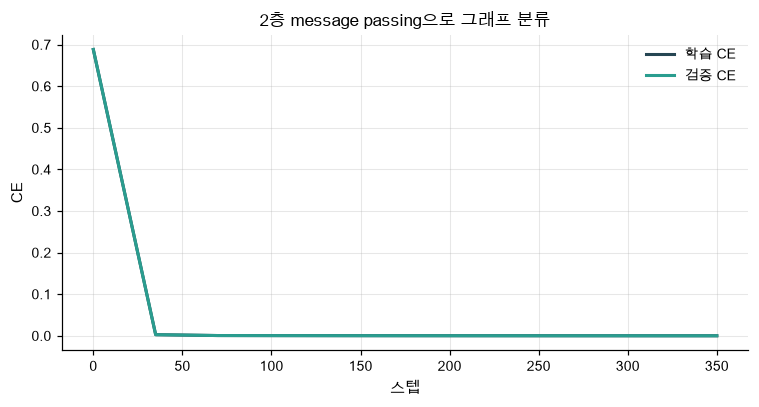

In [31]:
plot_curves(history["step"], {"학습 CE": history["train"], "검증 CE": history["valid"]},
            title="2층 message passing으로 그래프 분류", ylabel="CE")

🔍 **확인** · 검증 정확도가 95%를 넘고 학습 CE가 0.1 아래입니다. 파라미터는 백 몇십 개뿐입니다. 노드 순열이 다른 새 그래프에서도 맞는 이유는 다음 절의 성질 때문입니다.

### ✏️ 연습 4 · tanh 하나가 만드는 차이

인접 행렬 배치 `A` `(B, M, M)`과 모든 노드가 1인 특성에서 낸 활성 전 값 `Z` `(B, M, H)`로 활성 없이 평균낸 `linear_readout`과 tanh를 지난 뒤 평균낸 `readout`(둘 다 `(B, H)`) 두 줄을 채우세요. 사슬과 별은 평균 degree가 같아 선형 readout이 같지만, tanh를 지나면 갈립니다.

In [32]:
def exercise_nonlinear_readout(A, p):
    """연습 4: 상수 특성에서 선형 readout과 tanh를 지난 readout. A: (B, M, M) 0/1, p: {"Ws", "Wn": (1, H), "b": (H,)} → (linear_readout, readout: (B, H))."""
    assert A.ndim == 3, "A는 배치 축을 포함한 (B, M, M)이어야 합니다"
    B, M, _ = A.shape
    X = np.ones((B, M, 1))                                  # (B, M, 1): 잡음을 뺀 상수 특성 (4절 데이터의 1)
    Z = X @ p["Ws"] + (A @ X) @ p["Wn"] + p["b"]            # (B, M, H): 합 집계 한 층의 활성 전 값 (2절 수식)
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 활성 없이 노드들을 평균낸 linear_readout (B, H)와, tanh를 지난 뒤 노드들을 평균낸 readout (B, H)
    ### 힌트: 3절 graph_forward의 평균 readout 줄과 같습니다. 한 줄은 활성 없이, 다른 한 줄은 tanh를 지난 뒤 평균냅니다.
    raise NotImplementedError
    return linear_readout, readout

In [33]:
def check_nonlinear_readout(candidate):
    """4절의 사슬·별에서 선형 readout은 같고 tanh를 지난 readout은 다름을 확인합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: path6, star6 (4절 그림 셀) · gnn_layer_forward (2절)
    example_A = np.stack([path6, star6])                    # (2, 6, 6): 사슬과 별
    example_p = {"Ws": np.array([[0.4, -0.3, 0.7]]), "Wn": np.array([[0.3, 0.2, -0.5]]), "b": np.zeros(3)}   # (1, 3) 둘과 (3,)
    np.testing.assert_allclose(example_A.sum(axis=2).mean(axis=1), [10. / 6., 10. / 6.])   # 검산: 전제. 두 그래프의 평균 degree가 같음
    linear_readout, readout = candidate(example_A, example_p)
    assert readout.shape == (2, 3), f"readout은 (B, H) = (2, 3)이어야 하는데 {readout.shape}입니다"
    np.testing.assert_allclose(linear_readout[0], [0.9, 1. / 30., -2. / 15.])   # 검산: W_s + (10/6)·W_n. 예: 0.4 + (10/6)·0.3 = 0.9
    np.testing.assert_allclose(linear_readout[0], linear_readout[1], atol=1e-12)   # 검산: 활성이 없으면 평균 degree만 남아 두 그래프가 같음
    example_H, _ = gnn_layer_forward(np.ones((2, 6, 1)), example_A, example_p, "sum")
    np.testing.assert_allclose(readout, example_H.mean(axis=1))   # 검산: 2절 gnn_layer_forward의 H를 노드 축에서 평균낸 것과 같음
    assert np.abs(readout[0] - readout[1]).max() > 0.1, "tanh를 지난 readout은 두 그래프가 달라야 합니다 (tanh를 빼먹으면 같아집니다)"
    print("선형 readout은 같고, tanh를 지난 readout은 다릅니다.")

run_check(check_nonlinear_readout, exercise_nonlinear_readout, hint="linear_readout = Z.mean(axis=1), readout = np.tanh(Z).mean(axis=1)")

☐ exercise_nonlinear_readout: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: linear_readout = Z.mean(axis=1), readout = np.tanh(Z).mean(axis=1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
linear_readout = Z.mean(axis=1)
readout = np.tanh(Z).mean(axis=1)
```

</details>

## 🔑 5. 노드 번호를 바꾸어도 같은 그래프입니다

**이 절에서 가져갈 것:** 순열 $\Pi$로 노드를 재배열하면 $X'=\Pi X$, $A'=\Pi A\Pi^\top$입니다. 행과 열을 **둘 다** 바꿔야 같은 그래프이고, 그러면 노드 출력은 같은 순열로 바뀌고(등변) 그래프 logits는 그대로입니다(불변). backward의 $dX$도 같은 순열로 바뀌며 공유 파라미터의 미분은 같습니다.

> **용어** · **순열 행렬(permutation matrix)** $\Pi$: 행을 재배열하는 0/1 행렬. 코드에서는 `X[perm]`, `A[perm][:, perm]`. 05번의 등변·불변이 여기서는 "노드 번호 바꾸기"에 대한 성질입니다.

순열 행렬 $\Pi$로 노드를 재배열하면 $X'=\Pi X$, $A'=\Pi A\Pi^T$입니다. 받는 행과 보내는 열을 **둘 다** 바꿔야 같은 그래프를 나타냅니다. 그러면 $S'=\Pi S\Pi^T$이므로
$$S'X'=\Pi SX,\qquad H'=\Pi H.$$

재배열한 그래프의 이웃 합은 원래 이웃 합을 같은 순서로 재배열한 것이고, 층 출력도 마찬가지입니다.

노드별 출력은 같은 순서로 바뀌는 **equivariance**, 평균 readout과 그래프 logits는 그대로인 **invariance**를 갖습니다. 이 성질은 파라미터 학습 전후 모두 수식에서 나옵니다.

Backward에서도 상류 노드 기울기를 같은 순열로 바꾸면 dX는 같은 순열로 바뀌고, 공유 파라미터의 미분은 같습니다. 출력만 확인하지 않고 이 연결까지 검사합니다.

아래는 1절 그래프의 번호를 `[2, 0, 1]`로 바꾼 것입니다.

> **코드**
>
> - `X_valid[:3, permutation]`: 그래프 3개의 노드 축을 순열로 재배열. `A_valid[:3, permutation][:, :, permutation]`은 배치 축을 두고 행과 열을 같은 순열로.
> - `H[:, permutation]`: 노드 출력을 같은 순열로 재배열한 것. 등변성 검산의 비교 대상입니다.

In [34]:
# 쓰는 것: agg_A, agg_X (1절 손계산 셀)
perm_demo = np.array([2, 0, 1])                                    # 새 노드 i = 옛 노드 perm[i]
perm_A = agg_A[perm_demo][:, perm_demo]                            # (3, 3): 행과 열을 함께 재배열 = ΠAΠᵀ
perm_X = agg_X[perm_demo]                                          # (3, 2): ΠX
np.testing.assert_allclose(perm_A @ perm_X, (agg_A @ agg_X)[perm_demo])   # 검산: 이웃 합도 같은 순열 (S'X' = ΠSX)
print("A'\n", perm_A, "\n이웃 합' =", (perm_A @ perm_X).tolist(), "= 원래 이웃 합의 재배열")

A'
 [[0. 1. 0.]
 [1. 0. 1.]
 [0. 0. 0.]] 
이웃 합' = [[1.0, 2.0], [8.0, 12.0], [0.0, 0.0]] = 원래 이웃 합의 재배열


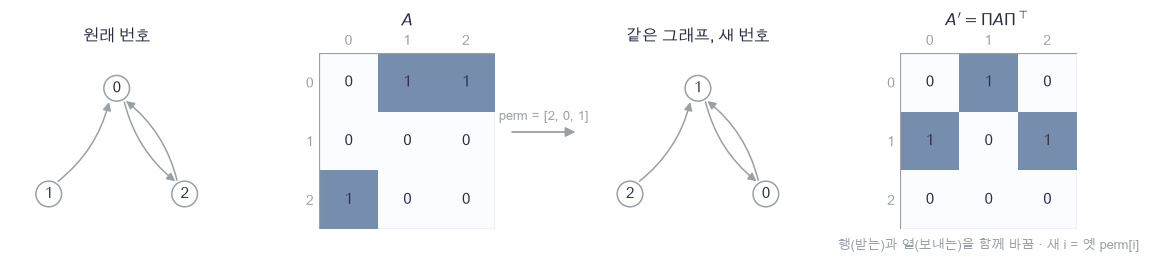

In [35]:
plot_permutation(agg_A, tri_positions, perm_demo, perm_A)

🔍 **확인** · 같은 화살표 그림인데 번호만 바뀌었습니다. 옛 노드 2가 새 0, 옛 0이 새 1, 옛 1이 새 2입니다. $A'$는 $A$의 행과 열을 그 순서로 함께 재배열한 것이고, 이웃 합도 같은 순서로 재배열됩니다.
행만 바꾸고 열을 안 바꾸면 다른 그래프가 됩니다. 아래 검산은 학습한 모델에서 노드 출력·입력 미분의 대응과 그래프 출력·공유 미분의 불변을 확인합니다.

In [36]:
# 쓰는 것: X_valid, A_valid, layers, head (4절 학습 셀) · gnn_layer_forward, gnn_layer_backward (2절) · graph_forward (3절)
permutation = np.array([4, 1, 5, 0, 3, 2])
Xp = X_valid[:3, permutation]                               # (3, 6, 1): 노드를 재배열한 입력
Ap = A_valid[:3, permutation][:, :, permutation]            # (3, 6, 6): 행·열을 함께 재배열
for mode in ["sum", "mean"]:
    H, cache = gnn_layer_forward(X_valid[:3], A_valid[:3], layers[0], mode)
    Hp, cachep = gnn_layer_forward(Xp, Ap, layers[0], mode)
    np.testing.assert_allclose(Hp, H[:, permutation], atol=1e-12)     # 검산: 노드 출력은 같은 순열로 (등변)
    logits, _ = graph_forward(X_valid[:3], A_valid[:3], layers, head, mode)
    logitsp, _ = graph_forward(Xp, Ap, layers, head, mode)
    np.testing.assert_allclose(logitsp, logits, atol=1e-12)           # 검산: 그래프 logits는 그대로 (불변)
    G = np.random.default_rng(108).normal(size=H.shape)               # 임의의 상류 기울기
    dx, grads = gnn_layer_backward(G, cache, layers[0])
    dxp, gradsp = gnn_layer_backward(G[:, permutation], cachep, layers[0])   # 상류 기울기도 같은 순열로
    np.testing.assert_allclose(dxp, dx[:, permutation], atol=1e-12)   # 검산: dX도 같은 순열로
    for key in grads:
        np.testing.assert_allclose(gradsp[key], grads[key], atol=1e-12)   # 검산: 공유 파라미터의 미분은 같음
    print(mode, "노드 출력·입력 미분 대응 / 그래프 출력·공유 미분 불변 통과")

sum 노드 출력·입력 미분 대응 / 그래프 출력·공유 미분 불변 통과
mean 노드 출력·입력 미분 대응 / 그래프 출력·공유 미분 불변 통과


🔍 **확인** · 합·평균 집계 모두에서 노드 출력과 $dX$는 순열대로 바뀌고, 그래프 logits와 $W_s, W_n, b$의 미분은 $10^{-12}$ 안에서 같습니다.

### ✏️ 연습 5 · 행과 열을 함께 바꾸기

노드 특성 `X` `(M, D)`, 인접 행렬 `A` `(M, M)`, 순열 `perm`(새 노드 `i`가 옛 노드 `perm[i]`)에서 재배열한 `Xp`와 `Ap`를 만드는 두 줄을 채우세요. `A`는 받는 행과 보내는 열을 **둘 다** 같은 순서로 바꿔야 같은 그래프입니다. 행만 바꾸면 검사가 잡습니다.

In [37]:
def exercise_permute_graph(X, A, perm):
    """연습 5: 노드 번호 바꾸기. X: (M, D), A: (M, M), perm: (M,) 정수 순열 (새 노드 i = 옛 노드 perm[i]) → (Xp: (M, D), Ap: (M, M))."""
    assert sorted(perm.tolist()) == list(range(A.shape[0])), "perm은 0부터 M−1을 한 번씩 담은 순열이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: 특성은 행만 재배열한 Xp = ΠX, 인접 행렬은 받는 행과 보내는 열을 둘 다 같은 순서로 재배열한 Ap = ΠAΠᵀ
    ### 힌트: 5절 순열 셀의 perm_X, perm_A 두 줄입니다. 행을 고른 결과에서 열을 한 번 더 고릅니다.
    raise NotImplementedError
    return Xp, Ap

In [38]:
def check_permute_graph(candidate):
    """1절 그래프를 [2, 0, 1]로 재배열한 손계산과 5절 순열 셀의 결과로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: perm_A, perm_X (5절 순열 셀)
    example_A = np.array([[0., 1., 1.], [0., 0., 0.], [1., 0., 0.]])   # (3, 3): 1절 그래프
    example_X = np.array([[1., 2.], [3., 4.], [5., 8.]])               # (3, 2)
    example_perm = np.array([2, 0, 1])                                 # 새 0 = 옛 2, 새 1 = 옛 0, 새 2 = 옛 1
    Xp, Ap = candidate(example_X, example_A, example_perm)
    np.testing.assert_allclose(Xp, [[5., 8.], [1., 2.], [3., 4.]])        # 검산: 행을 옛 2, 0, 1 순서로
    np.testing.assert_array_equal(Ap, [[0, 1, 0], [1, 0, 1], [0, 0, 0]])   # 검산: 새 0(옛 2)은 새 1(옛 0)에게서, 새 1(옛 0)은 새 0·2에게서 받음
    assert not np.array_equal(Ap, example_A[example_perm]), "행만 바꾼 것과는 달라야 합니다 (열도 같이 바꿔야 같은 그래프)"
    np.testing.assert_allclose(Ap @ Xp, [[1., 2.], [8., 12.], [0., 0.]])   # 검산: 이웃 합도 옛 [8,12],[0,0],[1,2]를 같은 순서로 재배열
    np.testing.assert_allclose(Ap, perm_A)                                 # 검산: 5절 순열 셀의 A'
    np.testing.assert_allclose(Xp, perm_X)                                 # 검산: 5절 순열 셀의 ΠX
    print("노드 번호 바꾸기: 손계산과 일치합니다. 행과 열을 함께 바꿔야 같은 그래프입니다.")

run_check(check_permute_graph, exercise_permute_graph, hint="Xp = X[perm], Ap = A[perm][:, perm]")

☐ exercise_permute_graph: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: Xp = X[perm], Ap = A[perm][:, perm]


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
Xp = X[perm]
Ap = A[perm][:, perm]
```

</details>

## 🔍 6. 표현력의 한계도 같은 코드로 확인하기

**첫 번째 한계: 평균 집계는 개수를 잃을 수 있습니다.** 모든 초기 노드 특성이 같고 고립 노드가 없다면, path와 star의 이웃 평균은 둘 다 그 같은 특성입니다. 이후 층도 모든 노드에 같은 규칙을 적용하므로 두 그래프의 평균 readout을 구별하지 못합니다. degree를 입력 특성에 넣거나 합 집계를 쓰면 이 특정 정보 손실을 피할 수 있습니다.

**두 번째 한계: 합 집계도 모든 그래프를 구별하지는 못합니다.** 6개 노드의 한 고리와, 각각 3개 노드로 된 분리된 두 고리는 모든 노드의 degree가 2입니다. 초기 특성이 모두 같으면 두 그래프의 각 노드는 매 층 같은 이웃 값 두 개를 받아 같은 표현을 가집니다. 이 message passing과 평균 readout으로는 연결성 차이를 구별할 수 없습니다.

이는 단순히 학습이 덜 된 현상이 아니라, 여기서 정의한 입력과 집계가 구별에 필요한 정보를 전달하지 않는 사례입니다. 모든 GNN 구조에 대한 불가능성 주장으로 넓히지는 않습니다.

> **코드**
>
> - `cycle6[0, -1] = cycle6[-1, 0] = 1`: 사슬의 양 끝을 이어 고리로.
> - `np.ones((3, 3)) - np.eye(3)`: 대각선만 0인 3×3 = 노드 3개가 서로 모두 연결된 삼각형. `triangles[:3, :3] = …`은 왼쪽 위 블록에 통째로 넣습니다.
> - `triangle_base + [-1.2, 0]`: 좌표 셋을 왼쪽으로 옮김(브로드캐스팅). 그림 배치용입니다.

In [39]:
# 쓰는 것: path6, star6 (4절 그림 셀) · layers, head (4절 학습 셀) · graph_forward (3절)
constant_X = np.ones((2, 6, 1))                             # (2, 6, 1): 모든 노드 특성이 같은 값 1
path_star = np.stack([path6, star6])                        # (2, 6, 6)
mean_logits, _ = graph_forward(constant_X, path_star, layers, head, mode="mean")
np.testing.assert_allclose(mean_logits[0], mean_logits[1], atol=1e-12)   # 검산: 평균 집계는 사슬과 별을 구별 못 함
cycle6 = path6.copy()
cycle6[0, -1] = cycle6[-1, 0] = 1                           # (6, 6): 한 고리 (사슬의 양 끝을 이음)
triangles = np.zeros((6, 6))
triangles[:3, :3] = np.ones((3, 3)) - np.eye(3)             # 분리된 두 3노드 고리 (삼각형 둘)
triangles[3:, 3:] = np.ones((3, 3)) - np.eye(3)
regular_pair = np.stack([cycle6, triangles])                # (2, 6, 6): 모든 노드의 degree가 2
regular_logits, _ = graph_forward(constant_X, regular_pair, layers, head, mode="sum")
np.testing.assert_allclose(regular_logits[0], regular_logits[1], atol=1e-12)   # 검산: 합 집계도 두 고리를 구별 못 함
triangle_angles = np.arange(3) * 2 * np.pi / 3              # 그림 좌표
triangle_base = np.stack([np.cos(triangle_angles), np.sin(triangle_angles)], axis=1) * 0.6
triangle_positions = np.vstack([triangle_base + [-1.2, 0], triangle_base + [1.2, 0]])
print("평균 집계의 path/star logits 차이:", np.max(np.abs(mean_logits[0] - mean_logits[1])))
print("합 집계의 한 고리/두 고리 logits 차이:", np.max(np.abs(regular_logits[0] - regular_logits[1])))

평균 집계의 path/star logits 차이: 0.0
합 집계의 한 고리/두 고리 logits 차이: 0.0


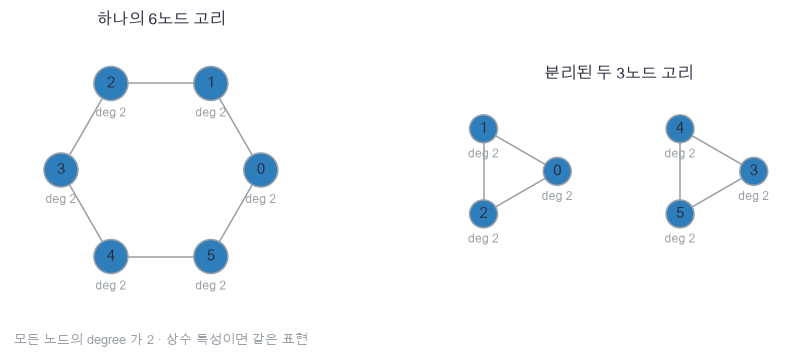

In [40]:
plot_two_graphs([cycle6, triangles], [circle, triangle_positions], [cycle6.sum(axis=1), triangles.sum(axis=1)],
                ["하나의 6노드 고리", "분리된 두 3노드 고리"], note="모든 노드의 degree 가 2 · 상수 특성이면 같은 표현")

🔍 **확인** · 상수 특성에서 평균 집계는 사슬과 별의 logits 차이가 0이고, 합 집계도 한 고리와 두 고리의 차이가 0입니다. 두 그래프의 모든 노드가 매 층 같은 값을 받기 때문입니다. 학습된 모델도 이 두 입력은 구별하지 못합니다.

## ✏️ 7. 직접 채워서 확인합니다

연습은 코딩 테스트처럼 **함수 뼈대가 미리 있고 핵심 한두 줄만 비어 있습니다.**
`raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓴 뒤, 셀을 실행하고 바로 아래 검사 셀을 실행하세요.
아직 채우지 않았으면 안내문만 나오고, 값이 다르면 "손계산과 다릅니다"가 나옵니다. 막히면 그 아래 "정답 보기"를 펼칩니다.

### 연습 A · 평균 집계 행렬 (1절)

0/1 인접 행렬 `A` $(B,M,M)$에서 각 행을 degree로 나눈 `S`를 만드는 두 줄을 채우세요. degree가 0인 행은 0으로 남깁니다.

In [41]:
def exercise_mean_aggregation(A):
    """연습 A: 평균 집계 행렬. A: (B, M, M) 0/1 → S: (B, M, M), 각 행을 degree로 나눔 (degree 0인 행은 0)."""
    assert A.ndim == 3, "A는 (B, M, M)이어야 합니다"
    assert np.all((A == 0) | (A == 1)), "A는 0/1 행렬이어야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: degree = 행마다 받는 이웃 수 (B, M, 1), S = A 를 max(degree, 1) 로 나눈 값
    ### 힌트: A.sum(axis=-1, keepdims=True), np.maximum(degree, 1)
    raise NotImplementedError
    return S

In [42]:
def check_mean_aggregation(candidate):
    """1절 손계산과 본문 aggregation_matrix, 행 합 1로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: agg_A, agg_S, agg_X, agg_mean (1절 손계산 셀) · aggregation_matrix (1절) · path_adjacency, star_adjacency (3절)
    np.testing.assert_allclose(candidate(agg_A[None])[0], agg_S)                                     # 검산: 1절 손계산 S
    np.testing.assert_allclose(candidate(agg_A[None])[0] @ agg_X, agg_mean)                          # 검산: 이웃 평균
    A_c = np.stack([path_adjacency(6), star_adjacency(6)])
    np.testing.assert_allclose(candidate(A_c), aggregation_matrix(A_c, "mean"))                       # 검산: 본문 함수와 같음
    np.testing.assert_allclose(candidate(A_c).sum(axis=-1), 1.)                                       # 검산: 이웃이 있으면 행 합 1
    print("평균 집계 행렬: 손계산·aggregation_matrix 와 일치합니다.")

run_check(check_mean_aggregation, exercise_mean_aggregation, hint="degree = A.sum(axis=-1, keepdims=True); S = A / np.maximum(degree, 1)")

☐ exercise_mean_aggregation: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: degree = A.sum(axis=-1, keepdims=True); S = A / np.maximum(degree, 1)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
degree = A.sum(axis=-1, keepdims=True)
S = A / np.maximum(degree, 1)
```

</details>

### ✏️ 연습 B · 한 층의 forward (2절)

노드 특성 `X` $(B,M,D)$, 집계 행렬 `S`, 파라미터 `p`에서 `Z`와 `H`를 만드는 두 줄을 채우세요.

In [43]:
def exercise_gnn_layer(X, S, p):
    """연습 B: 한 층의 forward. X: (B, M, D), S: (B, M, M), p: {"Ws", "Wn", "b"} → (H, Z: (B, M, H))."""
    assert X.shape[-1] == p["Ws"].shape[0] == p["Wn"].shape[0], "특성 폭 D가 Ws·Wn의 행 수와 같아야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: Z = 자기 특성 @ Ws + (이웃 집계 S @ X) @ Wn + b, H = tanh(Z)
    ### 힌트: 2절 gnn_layer_forward 의 두 줄입니다.
    raise NotImplementedError
    return H, Z

In [44]:
def check_gnn_layer_forward(candidate):
    """2절 손계산과 본문 gnn_layer_forward(평균 집계)로 검사합니다. 통과하면 메시지를 출력합니다."""
    # 쓰는 것: agg_A, agg_X (1절 손계산 셀) · layer_Ws, layer_Wn, layer_b, layer_Z, layer_H (2절 손계산 셀) · aggregation_matrix (1절) · gnn_layer_forward (2절) · path_adjacency, star_adjacency (3절)
    H_a, Z_a = candidate(agg_X[None], agg_A[None], {"Ws": layer_Ws, "Wn": layer_Wn, "b": layer_b})
    np.testing.assert_allclose(Z_a[0], layer_Z)                                                       # 검산: 2절 손계산 Z
    np.testing.assert_allclose(H_a[0], layer_H)                                                       # 검산: 2절 손계산 H
    rng_c = np.random.default_rng(101)
    A_c = np.stack([path_adjacency(4), star_adjacency(4)])
    X_c = rng_c.normal(size=(2, 4, 2))
    p_c = {"Ws": rng_c.normal(size=(2, 3)), "Wn": rng_c.normal(size=(2, 3)), "b": rng_c.normal(size=3)}
    S_c = aggregation_matrix(A_c, "mean")
    np.testing.assert_allclose(candidate(X_c, S_c, p_c)[0], gnn_layer_forward(X_c, A_c, p_c, "mean")[0])   # 검산: 본문 함수와 같음
    print("한 층의 forward: 손계산·gnn_layer_forward 와 일치합니다.")

run_check(check_gnn_layer_forward, exercise_gnn_layer, hint="Z = X @ p['Ws'] + (S @ X) @ p['Wn'] + p['b']; H = np.tanh(Z)")

☐ exercise_gnn_layer: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: Z = X @ p['Ws'] + (S @ X) @ p['Wn'] + p['b']; H = np.tanh(Z)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
Z = X @ p["Ws"] + (S @ X) @ p["Wn"] + p["b"]
H = np.tanh(Z)
```

</details>

### ✏️ 연습 C · 이웃 경로의 backward (2절)

활성 전 값의 기울기 `dZ` $(B,M,H)$, 집계 행렬 `S`, `Wn`에서 이웃 경로로 돌아오는 입력 기울기를 만드는 한 줄을 채우세요. 받는 노드에서 보내는 노드로 가므로 전치가 필요합니다.

In [45]:
def exercise_neighbor_backward(dZ, S, Wn):
    """연습 C: 이웃 경로의 입력 기울기 Sᵀ(dZ W_nᵀ). dZ: (B, M, H), S: (B, M, M), Wn: (D, H) → (B, M, D)."""
    assert dZ.shape[-1] == Wn.shape[1], "dZ의 폭은 Wn의 열 수 H여야 합니다"
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dX_neighbor = S 의 전치(마지막 두 축) @ (dZ 를 Wn 의 전치로 되돌린 값)
    ### 힌트: S.swapaxes(-1, -2), 2절의 dX 둘째 항입니다.
    raise NotImplementedError
    return dX_neighbor

In [46]:
def check_neighbor_backward(candidate):
    """합·평균 집계에서 self 경로 + 후보의 neighbor 경로가 본문 gnn_layer_backward의 dX와 같은지 검사합니다."""
    # 쓰는 것: agg_A (1절 손계산 셀) · path_adjacency (3절) · gnn_layer_forward, gnn_layer_backward (2절)
    rng_c = np.random.default_rng(102)
    A_c = np.stack([agg_A, path_adjacency(3)])                       # 방향 그래프와 사슬
    X_c = rng_c.normal(size=(2, 3, 2))
    p_c = {"Ws": rng_c.normal(size=(2, 3)), "Wn": rng_c.normal(size=(2, 3)), "b": np.zeros(3)}
    for mode in ("sum", "mean"):
        H_c, cache_c = gnn_layer_forward(X_c, A_c, p_c, mode)
        dH_c = rng_c.normal(size=H_c.shape)
        dZ_c = dH_c * (1 - H_c ** 2)                                  # tanh 도함수를 곱한 dZ
        dX_ref, _ = gnn_layer_backward(dH_c, cache_c, p_c)
        np.testing.assert_allclose(dZ_c @ p_c["Ws"].T + candidate(dZ_c, cache_c[1], p_c["Wn"]), dX_ref)   # 검산: self + neighbor = 본문의 dX (캐시의 S)
    print("이웃 경로의 backward: gnn_layer_backward 와 일치합니다 (전치 방향이 맞습니다).")

run_check(check_neighbor_backward, exercise_neighbor_backward, hint="dX_neighbor = S.swapaxes(-1, -2) @ (dZ @ Wn.T)")

☐ exercise_neighbor_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dX_neighbor = S.swapaxes(-1, -2) @ (dZ @ Wn.T)


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dX_neighbor = S.swapaxes(-1, -2) @ (dZ @ Wn.T)
```

</details>

### ✏️ 연습 D · 평균 readout의 backward (3절)

readout의 기울기 `dreadout` $(B,H)$와 노드 수 `M`에서 각 노드에 나눠 줄 `dH` $(B,M,H)$를 만드는 한 줄을 채우세요.

In [47]:
def exercise_readout_backward(dreadout, M):
    """연습 D: 평균 readout의 backward. dreadout: (B, H), M: 노드 수 → dH: (B, M, H), 노드마다 dr/M."""
    B, H = dreadout.shape
    ### 이 주석 아래에 다음을 구현하세요.
    ### 구현할 내용: dH = dreadout / M 을 노드 축에 M 번 복제한 (B, M, H) 배열
    ### 힌트: np.broadcast_to((dreadout / M)[:, None, :], (B, M, H)) 또는 np.repeat
    raise NotImplementedError
    return dH

In [48]:
def check_readout_backward(candidate):
    """모양과, readout = 노드 평균인 스칼라의 중심차분으로 검사합니다. 통과하면 메시지를 출력합니다."""
    rng_c = np.random.default_rng(103)
    H_c = rng_c.normal(size=(2, 5, 3))                              # (B, M, H)
    G_c = rng_c.normal(size=(2, 3))                                 # (B, H): readout의 상류 기울기
    dH_c = candidate(G_c, 5)
    assert dH_c.shape == (2, 5, 3), f"모양은 (B, M, H) = (2, 5, 3)이어야 하는데 {dH_c.shape}입니다"

    def readout_scalar():
        """검사기용: 스칼라 L = Σ mean_node(H) ⊙ G."""
        return float(np.sum(H_c.mean(axis=1) * G_c))

    numeric_c = numerical_gradient(readout_scalar, H_c)             # H_c를 흔들어 잰 중심차분
    np.testing.assert_allclose(dH_c, numeric_c, atol=1e-8)          # 검산: 노드마다 G/M
    print("평균 readout backward: 모든 노드가 같은 dr/M 을 받습니다.")

run_check(check_readout_backward, exercise_readout_backward, hint="dH = np.broadcast_to((dreadout / M)[:, None, :], (B, M, H))")

☐ exercise_readout_backward: 아직 채우지 않았습니다. `raise NotImplementedError` 줄을 지우고 그 자리에 코드를 쓰세요.
   힌트: dH = np.broadcast_to((dreadout / M)[:, None, :], (B, M, H))


📎 **정답** · 막히면 펼쳐 보고, 다시 접고 스스로 써 보세요.

<details>
<summary>정답 보기</summary>

```python
dH = np.broadcast_to((dreadout / M)[:, None, :], (B, M, H))
```

</details>

### 🔍 완성 예제 · 검사기가 잡는 오답과 노드 수 변경

아래는 이웃 기울기를 forward와 같은 방향($S$ 그대로)으로 보낸 오답입니다. 2절의 검사기가 거부하는지 실행합니다. 이어서 노드 6개로 학습한 모델을 추가 갱신 없이 8노드 그래프에 적용합니다. 가중치 shape는 그대로지만 데이터의 degree 분포가 달라집니다.

> **코드** · `try: … except AssertionError as error: … else: …`: 검사기가 assert로 멈추면 `except`로 가고(오답을 잡은 것) 그 메시지가 `error`에 담깁니다. 멈추지 않으면 `else`로 갑니다. 여기서는 오답이 **잡혀야** 정상이므로 `else`에서 일부러 오류를 냅니다.

In [49]:
def wrong_neighbor_direction(dH, cache, p):
    """일부러 틀린 backward: 이웃 경로의 기울기를 Sᵀ가 아니라 S로 보냅니다. 인자·반환은 gnn_layer_backward와 같습니다."""
    # 쓰는 것: gnn_layer_backward (2절)
    X, S, messages, H = cache
    _, grads = gnn_layer_backward(dH, cache, p)             # 파라미터 기울기는 맞는 것을 그대로
    dZ = dH * (1 - H ** 2)
    dX = dZ @ p["Ws"].T + S @ (dZ @ p["Wn"].T)              # 오답: 전치 없이 S (맞는 식은 S.swapaxes(-1, -2) @ …)
    return dX, grads

In [50]:
# 쓰는 것: check_gnn_layer (2절) · graph_data, ce_loss (4절) · graph_forward (3절) · layers, head (4절 학습 셀)
try:
    check_gnn_layer(wrong_neighbor_direction)
except AssertionError as failure:
    print("의도적 오답 검출: 이웃 미분의 전치 누락", failure)   # failure = 검사기의 메시지 (mode, 이름, 오차)
else:
    raise AssertionError("검사기가 오답을 놓쳤습니다")
X8, A8, y8 = graph_data(64, 8, 109)                         # 노드 8개짜리 새 그래프
logits8, _ = graph_forward(X8, A8, layers, head)            # 6노드로 학습한 파라미터를 그대로 적용
print(f"추가 갱신 없는 8노드: CE {ce_loss(logits8, y8)[0]:.6f}, 정확도 {np.mean(logits8.argmax(axis=-1) == y8):.1%}")

의도적 오답 검출: 이웃 미분의 전치 누락 ('sum', 'X', 0.848897776249473)
추가 갱신 없는 8노드: CE 0.000045, 정확도 100.0%


### 📎 공유 방식을 연결하기

| 구조 | 이웃을 정하는 방법 | 파라미터가 공유되는 축 | 입력 기울기가 모이는 이유 |
|---|---|---|---|
| CNN | 공간의 고정된 패치 | 이미지의 위치 | 한 픽셀이 여러 패치에 등장 |
| RNN·LSTM·GRU | 이전 시각의 상태 | 시간 | 같은 상태가 미래 경로와 손실에 사용 |
| GNN | 주어진 edge | 노드·edge의 반복 규칙 | 한 노드가 여러 이웃에게 정보를 전달 |
| Attention·Transformer | Q·K로 계산한 가중치와 mask | 위치의 투영·FFN | 각 값이 여러 query에 읽힘 |

공유는 같은 변수를 여러 계산에 다시 사용한다는 뜻이고, 미분은 그 사용 경로들의 **합**입니다. 이제 구조를 바꿀 때 무엇이 바뀌고 CE·MSE·optimizer 중 무엇을 유지할 수 있는지 구분할 수 있어야 합니다.

### ✏️ 준비도 질문 · 다음으로 가기 전, 네 가지를 따로 확인합니다

🔑 표시가 붙은 절의 내용만으로 답할 수 있어야 합니다.

- **설명:** 인접 행렬 방향, 자기 경로, 이웃 집계, readout의 역할을 구분할 수 있나요? → 1–3절
- **수식:** $S$의 정규화와 전치가 나타나는 위치, 노드 평균의 미분을 쓸 수 있나요? → 1–3절
- **구현:** 방향·고립 노드·노드 수 변화를 처리하며 공유 미분을 누적할 수 있나요? → 2·4절
- **변형:** 노드 출력의 등변성과 그래프 출력의 불변성을 검산하고, 노드 분류로 바꾸면 readout 대신 각 $H_i$에 head를 붙일 때 logits의 shape와 평균낼 유효 노드 수를 말할 수 있나요? → 3·5절

다음은 [10b CVNN](10b_cvnn.ipynb)입니다. 5절의 순열 등변·불변을 전체 위상 회전 $z\mapsto e^{i\varphi}z$에 대한 등변·불변으로 넓히고, 복소수 가중치의 기울기를 직접 계산합니다. 기본 아키텍처는 10b에서 끝나고, 그 뒤 [11 · 투영·공분산·SVD·PCA](../02_연결/11_linear_algebra.ipynb)로 넘어갑니다.

📎 [Gilmer 등의 Message Passing Neural Networks](https://arxiv.org/abs/1704.01212)는 메시지 전달과 readout으로 그래프 모델을 설명하는 틀을 제공합니다. 여기서는 edge 특성 없이 self와 합/평균 이웃을 결합한 교육용 인스턴스를 구현했으며, 특정 GCN·GraphSAGE 라이브러리의 동일 재현은 아닙니다.